In [ ]:
pip install pennylane


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 42.1 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [ ]:
# =========================================================
# CELL 1: Train CNN+MLP and CNN+VQC, save everything needed
# =========================================================
# !pip install pennylane torch torchvision scikit-learn tqdm -q

from google.colab import drive
drive.mount('/content/drive')

import os, random, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, roc_auc_score)
from tqdm import tqdm
import pennylane as qml
from collections import Counter

# -------------------- Config --------------------
SEED             = 42
torch.set_default_dtype(torch.float32)
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_DIR         = "/content/drive/MyDrive/skin_cancer_data"
TRAIN_DIR        = os.path.join(DATA_DIR, "train")
TEST_DIR         = os.path.join(DATA_DIR, "test")

IMG_SIZE         = 224
BATCH_SIZE       = 16
NUM_WORKERS      = 2
PCA_DIM          = 6      # stable config from prior debugging
VQC_LAYERS       = 2
EPOCHS_CLASSICAL = 30
EPOCHS_VQC       = 10
LR               = 1e-3
NUM_CLASSES      = 2

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()

# -------------------- Transforms --------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# -------------------- Load Dataset --------------------
train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)
class_names = list(train_full.class_to_idx.keys())
print(f"Classes: {class_names} | Train: {len(train_full)} | Test: {len(test_ds)}")

val_size   = int(0.15 * len(train_full))
train_size = len(train_full) - val_size
train_ds, val_ds = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
# IMPORTANT: deep-copy the underlying dataset before swapping transform,
# so we don't mutate train_full's transform out from under train_ds
import copy
val_ds.dataset = copy.deepcopy(train_full)
val_ds.dataset.transform = eval_tf

train_labels = [train_full.targets[i] for i in train_ds.indices]
weights      = [1.0 / Counter(train_labels)[l] for l in train_labels]
sampler      = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

# -------------------- EfficientNet-B3 Backbone (frozen) --------------------
print("Loading EfficientNet-B3 backbone (frozen)...")
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
backbone.classifier = nn.Identity()
backbone = backbone.to(DEVICE)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

def extract_features(loader, desc="Extracting"):
    feats, labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc):
            feats.append(backbone(x.to(DEVICE)).cpu().numpy())
            labels.append(y.numpy())
    return np.vstack(feats), np.concatenate(labels)

print("Extracting CNN features...")
train_feat, train_y = extract_features(train_loader, "Train")
val_feat,   val_y   = extract_features(val_loader,   "Val  ")
test_feat,  test_y  = extract_features(test_loader,  "Test ")

# -------------------- Prepare Inputs --------------------
X_train_mlp = torch.tensor(train_feat, dtype=torch.float32).to(DEVICE)
X_val_mlp   = torch.tensor(val_feat,   dtype=torch.float32).to(DEVICE)
X_test_mlp  = torch.tensor(test_feat,  dtype=torch.float32).to(DEVICE)
y_train_t   = torch.tensor(train_y, dtype=torch.long).to(DEVICE)
y_val_t     = torch.tensor(val_y,   dtype=torch.long).to(DEVICE)

pca    = PCA(n_components=PCA_DIM, random_state=SEED)
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_vqc = torch.tensor(scaler.fit_transform(pca.fit_transform(train_feat)), dtype=torch.float32).to(DEVICE)
X_val_vqc   = torch.tensor(scaler.transform(pca.transform(val_feat)), dtype=torch.float32).to(DEVICE)
X_test_vqc  = torch.tensor(scaler.transform(pca.transform(test_feat)), dtype=torch.float32).to(DEVICE)

# =========================================================
# CLASSICAL MLP
# =========================================================
print("\n" + "="*60 + "\nTRAINING CNN + MLP\n" + "="*60)

class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, NUM_CLASSES)
        )
    def forward(self, x): return self.net(x)

mlp       = ImprovedMLP(train_feat.shape[1]).to(DEVICE)
optimizer = optim.AdamW(mlp.parameters(), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_CLASSICAL)
loss_fn   = nn.CrossEntropyLoss()

best_mlp_acc, best_mlp_state = 0, None
mlp_history = {'loss': [], 'val_acc': []}

for epoch in range(EPOCHS_CLASSICAL):
    mlp.train()
    optimizer.zero_grad()
    loss = loss_fn(mlp(X_train_mlp), y_train_t)
    loss.backward(); optimizer.step(); scheduler.step()

    mlp.eval()
    with torch.no_grad():
        val_acc = accuracy_score(y_val_t.cpu(), torch.argmax(mlp(X_val_mlp), dim=1).cpu())

    mlp_history['loss'].append(loss.item())
    mlp_history['val_acc'].append(val_acc)

    if val_acc > best_mlp_acc:
        best_mlp_acc, best_mlp_state = val_acc, {k: v.clone() for k, v in mlp.state_dict().items()}
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:>3}/{EPOCHS_CLASSICAL} | Loss: {loss.item():.4f} | Val Acc: {val_acc:.4f}")

mlp.load_state_dict(best_mlp_state)
mlp.eval()
with torch.no_grad():
    mlp_probs_test = torch.softmax(mlp(X_test_mlp), dim=1).cpu().numpy()
    mlp_preds      = np.argmax(mlp_probs_test, axis=1)
print(f"Best MLP Val Accuracy: {best_mlp_acc*100:.2f}%")

# =========================================================
# QUANTUM VQC
# =========================================================
print("\n" + "="*60 + "\nTRAINING CNN + VQC\n" + "="*60)

n_qubits = PCA_DIM
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i] * np.pi, wires=i)
        qml.RZ(inputs[i] * np.pi / 2, wires=i)
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class ImprovedVQC(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(VQC_LAYERS, n_qubits, 3) * 0.1)
        self.fc = nn.Sequential(nn.Linear(n_qubits, 16), nn.GELU(), nn.Linear(16, NUM_CLASSES))
    def forward(self, x):
        if x.dim() == 1: x = x.unsqueeze(0)
        outputs = [torch.stack(list(quantum_circuit(x[i], self.weights))) for i in range(x.shape[0])]
        return self.fc(torch.stack(outputs).float())

vqc           = ImprovedVQC().to(DEVICE)
vqc_optimizer = optim.AdamW(vqc.parameters(), lr=1e-3, weight_decay=1e-3)
vqc_scheduler = optim.lr_scheduler.CosineAnnealingLR(vqc_optimizer, T_max=EPOCHS_VQC)
vqc_loader    = DataLoader(torch.utils.data.TensorDataset(X_train_vqc, y_train_t), batch_size=4, shuffle=True)

best_vqc_acc, best_vqc_state = 0, None
vqc_history = {'loss': [], 'val_acc': []}

for epoch in range(EPOCHS_VQC):
    vqc.train()
    total_loss = 0
    for xb, yb in tqdm(vqc_loader, desc=f"VQC Epoch {epoch+1}/{EPOCHS_VQC}", leave=False):
        vqc_optimizer.zero_grad()
        loss = loss_fn(vqc(xb), yb)
        loss.backward(); vqc_optimizer.step()
        total_loss += loss.item()
    vqc_scheduler.step()

    vqc.eval()
    with torch.no_grad():
        val_acc = accuracy_score(val_y, torch.argmax(vqc(X_val_vqc), dim=1).cpu().numpy())

    vqc_history['loss'].append(total_loss)
    vqc_history['val_acc'].append(val_acc)

    if val_acc > best_vqc_acc:
        best_vqc_acc, best_vqc_state = val_acc, {k: v.clone() for k, v in vqc.state_dict().items()}
    print(f"  Epoch {epoch+1:>3}/{EPOCHS_VQC} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

vqc.load_state_dict(best_vqc_state)
vqc.eval()
with torch.no_grad():
    vqc_probs_test = torch.softmax(vqc(X_test_vqc), dim=1).cpu().numpy()
    vqc_preds      = np.argmax(vqc_probs_test, axis=1)
print(f"Best VQC Val Accuracy: {best_vqc_acc*100:.2f}%")

# =========================================================
# ENSEMBLE METRICS (computed once, saved for Cell 2)
# =========================================================
ensemble_probs = (mlp_probs_test + vqc_probs_test) / 2.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

def compute_metrics(y_true, y_pred, probs):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(y_true, probs[:, 1])
    except Exception:
        auc = float('nan')
    return acc, prec, rec, f1, auc

mlp_m = compute_metrics(test_y, mlp_preds, mlp_probs_test)
vqc_m = compute_metrics(test_y, vqc_preds, vqc_probs_test)
ens_m = compute_metrics(test_y, ensemble_preds, ensemble_probs)

print("\n" + "="*72)
print(f"{'Model':<26} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-"*72)
for name, m in [("CNN + MLP (Classical)", mlp_m), ("CNN + VQC (Quantum)", vqc_m), ("Hybrid Ensemble", ens_m)]:
    print(f"{name:<26} {m[0]*100:>9.2f}% {m[1]*100:>9.2f}% {m[2]*100:>7.2f}% {m[3]*100:>7.2f}% {m[4]:>8.4f}")
print("="*72)

# =========================================================
# SAVE — Drive (persistent) + /content tmp (fast) + local download
# =========================================================
checkpoint = {
    'mlp_state':      mlp.state_dict(),
    'vqc_state':      vqc.state_dict(),
    'pca':            pca,
    'scaler':         scaler,
    'class_names':    class_names,
    'config': {
        'PCA_DIM': PCA_DIM, 'VQC_LAYERS': VQC_LAYERS, 'NUM_CLASSES': NUM_CLASSES,
        'IMG_SIZE': IMG_SIZE,
    },
    # saved so Cell 2 can redraw graphs without retraining
    'mlp_history':    mlp_history,
    'vqc_history':    vqc_history,
    'test_y':         test_y,
    'mlp_preds':      mlp_preds,      'mlp_probs_test': mlp_probs_test,
    'vqc_preds':      vqc_preds,      'vqc_probs_test': vqc_probs_test,
    'ensemble_preds': ensemble_preds, 'ensemble_probs': ensemble_probs,
    'mlp_test_acc':   mlp_m[0], 'vqc_test_acc': vqc_m[0], 'ens_test_acc': ens_m[0],
}

CKPT_NAME = "skin_cancer_hybrid.pth"

drive_save_dir = os.path.join(DATA_DIR, "saved_models")
os.makedirs(drive_save_dir, exist_ok=True)
drive_path = os.path.join(drive_save_dir, CKPT_NAME)
torch.save(checkpoint, drive_path)
print(f"Saved to Drive → {drive_path}")

tmp_path = os.path.join("/content", CKPT_NAME)
torch.save(checkpoint, tmp_path)
print(f"Saved to Colab tmp → {tmp_path}")

from google.colab import files
files.download(tmp_path)
print("Triggered browser download — keep this .pth file safe on your machine.")
print("\nDone training. You can now run Cell 2 (analysis) and Cell 3 (inference)")
print("independently, any time, without rerunning this cell.")

Mounted at /content/drive
Using device: cpu
Classes: ['benign', 'malignant'] | Train: 9605 | Test: 1000
Loading EfficientNet-B3 backbone (frozen)...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 103MB/s]


Extracting CNN features...


Train:   0%|          | 0/511 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Test : 100%|██████████| 63/63 [02:52<00:00,  2.74s/it]



TRAINING CNN + MLP
  Epoch   5/30 | Loss: 0.3606 | Val Acc: 0.8694
  Epoch  10/30 | Loss: 0.2997 | Val Acc: 0.8653
  Epoch  15/30 | Loss: 0.2741 | Val Acc: 0.8674
  Epoch  20/30 | Loss: 0.2585 | Val Acc: 0.8799
  Epoch  25/30 | Loss: 0.2523 | Val Acc: 0.8819
  Epoch  30/30 | Loss: 0.2506 | Val Acc: 0.8833
Best MLP Val Accuracy: 88.33%

TRAINING CNN + VQC


...

  Epoch   9/10 | Loss: 1008.2296 | Val Acc: 0.7514


  Epoch  10/10 | Loss: 1007.1572 | Val Acc: 0.7500
Best VQC Val Accuracy: 75.83%

Model                        Accuracy  Precision   Recall       F1      AUC
------------------------------------------------------------------------
CNN + MLP (Classical)          88.70%     88.99%   88.70%   88.68%   0.9667
CNN + VQC (Quantum)            76.50%     77.67%   76.50%   76.25%   0.8672
Hybrid Ensemble                86.50%     87.21%   86.50%   86.44%   0.9536
Saved to Drive → /content/drive/MyDrive/skin_cancer_data/saved_models/skin_cancer_hybrid.pth
Saved to Colab tmp → /content/skin_cancer_hybrid.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Triggered browser download — keep this .pth file safe on your machine.

Done training. You can now run Cell 2 (analysis) and Cell 3 (inference)
independently, any time, without rerunning this cell.


Loading from Colab tmp: /content/skin_cancer_hybrid.pth


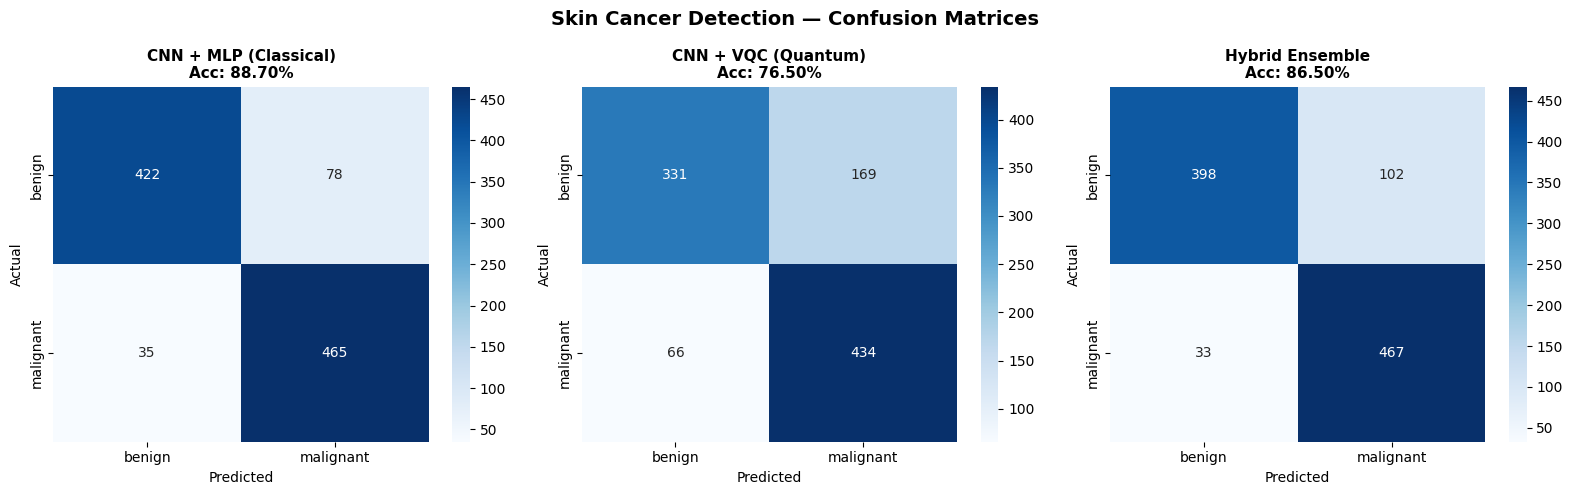

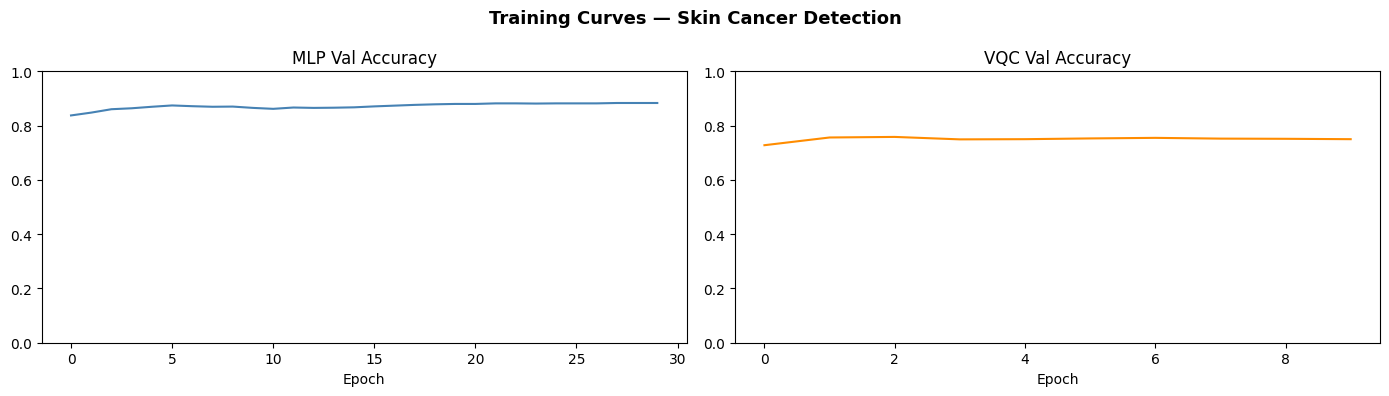


MLP Test Acc: 88.70% | VQC Test Acc: 76.50% | Ensemble Test Acc: 86.50%


In [ ]:
# =========================================================
# CELL 2: Load saved checkpoint, plot confusion matrices +
# training curves. Independent of Cell 1 — safe to run
# after a page refresh / new runtime.
# =========================================================
import os, torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

CKPT_NAME = "skin_cancer_hybrid.pth"
DRIVE_PATH = "/content/drive/MyDrive/skin_cancer_data/saved_models/" + CKPT_NAME
TMP_PATH   = "/content/" + CKPT_NAME

def load_checkpoint():
    # 1) Try Colab tmp (fastest, survives within the same runtime)
    if os.path.exists(TMP_PATH):
        print(f"Loading from Colab tmp: {TMP_PATH}")
        return torch.load(TMP_PATH, map_location="cpu", weights_only=False)
    # 2) Try Drive (survives refresh, as long as Drive is mounted)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    if os.path.exists(DRIVE_PATH):
        print(f"Loading from Drive: {DRIVE_PATH}")
        return torch.load(DRIVE_PATH, map_location="cpu", weights_only=False)
    # 3) Fall back: ask user to upload the .pth they downloaded from Cell 1
    print("No saved checkpoint found in tmp or Drive.")
    print(f"Please upload the '{CKPT_NAME}' file you downloaded from Cell 1:")
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    return torch.load(fname, map_location="cpu", weights_only=False)

ckpt = load_checkpoint()

class_names     = ckpt['class_names']
mlp_history     = ckpt['mlp_history']
vqc_history     = ckpt['vqc_history']
test_y          = ckpt['test_y']
mlp_preds       = ckpt['mlp_preds']
vqc_preds       = ckpt['vqc_preds']
ensemble_preds  = ckpt['ensemble_preds']
mlp_test_acc    = ckpt['mlp_test_acc']
vqc_test_acc    = ckpt['vqc_test_acc']
ens_test_acc    = ckpt['ens_test_acc']

# -------------------- Confusion Matrices --------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Skin Cancer Detection — Confusion Matrices", fontsize=14, weight='bold')
for ax, preds, title in zip(
    axes, [mlp_preds, vqc_preds, ensemble_preds],
    ["CNN + MLP (Classical)", "CNN + VQC (Quantum)", "Hybrid Ensemble"]
):
    cm = confusion_matrix(test_y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{title}\nAcc: {accuracy_score(test_y, preds)*100:.2f}%", fontsize=11, weight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices_skin.png", dpi=150, bbox_inches='tight')
plt.show()

# -------------------- Training Curves --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Training Curves — Skin Cancer Detection", fontsize=13, weight='bold')
axes[0].plot(mlp_history['val_acc'], color='steelblue')
axes[0].set(title="MLP Val Accuracy", xlabel="Epoch", ylim=(0, 1))
axes[1].plot(vqc_history['val_acc'], color='darkorange')
axes[1].set(title="VQC Val Accuracy", xlabel="Epoch", ylim=(0, 1))
plt.tight_layout()
plt.savefig("training_curves_skin.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMLP Test Acc: {mlp_test_acc*100:.2f}% | VQC Test Acc: {vqc_test_acc*100:.2f}% | Ensemble Test Acc: {ens_test_acc*100:.2f}%")

Loading from Colab tmp: /content/skin_cancer_hybrid.pth
Loading EfficientNet-B3 backbone (frozen)...
Model rebuilt and loaded from checkpoint. Ready for inference.

Upload skin image(s) to test (jpg/png):


Saving melanoma_10317.jpg to melanoma_10317.jpg
[1/1] melanoma_10317.jpg


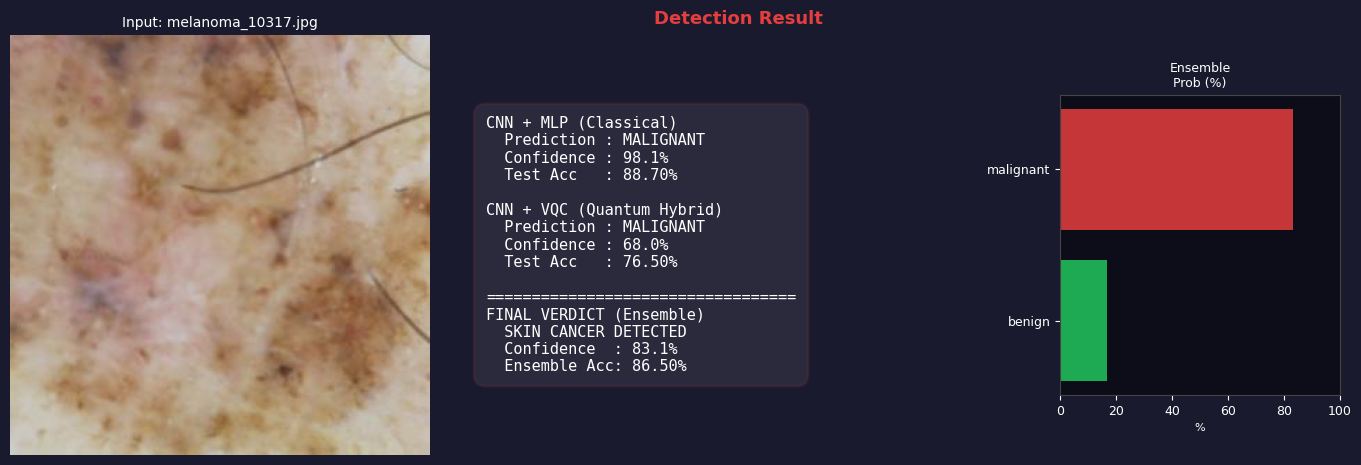

Saved → result_melanoma_10317.png


In [ ]:
# =========================================================
# CELL 3: Load saved checkpoint, rebuild model, upload an
# image and run inference. Independent of Cells 1 & 2.
# =========================================================
import os, torch, torch.nn as nn
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

CKPT_NAME = "skin_cancer_hybrid.pth"
DRIVE_PATH = "/content/drive/MyDrive/skin_cancer_data/saved_models/" + CKPT_NAME
TMP_PATH   = "/content/" + CKPT_NAME
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_checkpoint():
    if os.path.exists(TMP_PATH):
        print(f"Loading from Colab tmp: {TMP_PATH}")
        return torch.load(TMP_PATH, map_location="cpu", weights_only=False)
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    if os.path.exists(DRIVE_PATH):
        print(f"Loading from Drive: {DRIVE_PATH}")
        return torch.load(DRIVE_PATH, map_location="cpu", weights_only=False)
    print("No saved checkpoint found in tmp or Drive.")
    print(f"Please upload the '{CKPT_NAME}' file you downloaded from Cell 1:")
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    return torch.load(fname, map_location="cpu", weights_only=False)

ckpt = load_checkpoint()
class_names = ckpt['class_names']
pca, scaler = ckpt['pca'], ckpt['scaler']
cfg = ckpt['config']
PCA_DIM, VQC_LAYERS, NUM_CLASSES, IMG_SIZE = cfg['PCA_DIM'], cfg['VQC_LAYERS'], cfg['NUM_CLASSES'], cfg['IMG_SIZE']
mlp_test_acc, vqc_test_acc, ens_test_acc = ckpt['mlp_test_acc'], ckpt['vqc_test_acc'], ckpt['ens_test_acc']

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# -------------------- Rebuild backbone --------------------
print("Loading EfficientNet-B3 backbone (frozen)...")
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
backbone.classifier = nn.Identity()
backbone = backbone.to(DEVICE)
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

# -------------------- Rebuild MLP --------------------
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 64),        nn.BatchNorm1d(64),  nn.GELU(), nn.Dropout(0.3),
            nn.Linear(64, NUM_CLASSES)
        )
    def forward(self, x): return self.net(x)

mlp = ImprovedMLP(1536).to(DEVICE)  # EfficientNet-B3 feature dim
mlp.load_state_dict(ckpt['mlp_state'])
mlp.eval()

# -------------------- Rebuild VQC --------------------
n_qubits = PCA_DIM
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    for i in range(n_qubits):
        qml.RY(inputs[i] * np.pi, wires=i)
        qml.RZ(inputs[i] * np.pi / 2, wires=i)
    for l in range(weights.shape[0]):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

class ImprovedVQC(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(VQC_LAYERS, n_qubits, 3) * 0.1)
        self.fc = nn.Sequential(nn.Linear(n_qubits, 16), nn.GELU(), nn.Linear(16, NUM_CLASSES))
    def forward(self, x):
        if x.dim() == 1: x = x.unsqueeze(0)
        outputs = [torch.stack(list(quantum_circuit(x[i], self.weights))) for i in range(x.shape[0])]
        return self.fc(torch.stack(outputs).float())

vqc = ImprovedVQC().to(DEVICE)
vqc.load_state_dict(ckpt['vqc_state'])
vqc.eval()

print("Model rebuilt and loaded from checkpoint. Ready for inference.")

# =========================================================
# PREDICTION FUNCTIONS
# =========================================================
def predict_skin_cancer(image_path):
    img = Image.open(image_path).convert('RGB')
    img_tensor = eval_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = backbone(img_tensor).cpu().numpy()

    feat_mlp = torch.tensor(feat, dtype=torch.float32).to(DEVICE)
    feat_vqc = torch.tensor(scaler.transform(pca.transform(feat)), dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        mlp_p = torch.softmax(mlp(feat_mlp), dim=1)[0].cpu().numpy()
        vqc_p = torch.softmax(vqc(feat_vqc), dim=1)[0].cpu().numpy()
    ens_p = (mlp_p + vqc_p) / 2.0

    return {
        'image': img,
        'mlp':      {'label': class_names[np.argmax(mlp_p)], 'conf': mlp_p.max()*100, 'probs': {c: mlp_p[i]*100 for i, c in enumerate(class_names)}},
        'vqc':      {'label': class_names[np.argmax(vqc_p)], 'conf': vqc_p.max()*100, 'probs': {c: vqc_p[i]*100 for i, c in enumerate(class_names)}},
        'ensemble': {'label': class_names[np.argmax(ens_p)], 'conf': ens_p.max()*100, 'probs': {c: ens_p[i]*100 for i, c in enumerate(class_names)}}
    }

def display_prediction(r, fname):
    NEGATIVE_KEYWORDS = ['BENIGN', 'NON', 'NORMAL', 'HEALTHY', 'NEGATIVE']
    ens_label = r['ensemble']['label'].upper()
    is_cancer = not any(kw in ens_label for kw in NEGATIVE_KEYWORDS)
    verdict = 'SKIN CANCER DETECTED' if is_cancer else 'NO SKIN CANCER (BENIGN)'
    color = '#e53e3e' if is_cancer else '#22c55e'

    fig = plt.figure(figsize=(14, 5), facecolor='#1a1a2e')
    ax_img = fig.add_axes([0.02, 0.08, 0.30, 0.84])
    ax_txt = fig.add_axes([0.34, 0.08, 0.40, 0.84])
    ax_bar = fig.add_axes([0.77, 0.20, 0.20, 0.60])

    ax_img.imshow(r['image']); ax_img.axis('off')
    ax_img.set_title(f"Input: {fname}", color='white', fontsize=10, pad=6)

    txt = (
        f"CNN + MLP (Classical)\n"
        f"  Prediction : {r['mlp']['label'].upper()}\n"
        f"  Confidence : {r['mlp']['conf']:.1f}%\n"
        f"  Test Acc   : {mlp_test_acc*100:.2f}%\n\n"
        f"CNN + VQC (Quantum Hybrid)\n"
        f"  Prediction : {r['vqc']['label'].upper()}\n"
        f"  Confidence : {r['vqc']['conf']:.1f}%\n"
        f"  Test Acc   : {vqc_test_acc*100:.2f}%\n\n"
        f"{'='*34}\n"
        f"FINAL VERDICT (Ensemble)\n"
        f"  {verdict}\n"
        f"  Confidence  : {r['ensemble']['conf']:.1f}%\n"
        f"  Ensemble Acc: {ens_test_acc*100:.2f}%"
    )
    ax_txt.set_facecolor('#0d0d1a')
    ax_txt.text(0.05, 0.5, txt, transform=ax_txt.transAxes, fontsize=11, va='center',
                fontfamily='monospace', color='white',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='#ffffff', alpha=0.07, edgecolor=color, linewidth=2.5))
    ax_txt.axis('off')
    ax_txt.set_title('Detection Result', color=color, fontsize=13, weight='bold', pad=8)

    labels = list(r['ensemble']['probs'].keys())
    probs = list(r['ensemble']['probs'].values())
    bar_colors = ['#e53e3e' if 'MALIG' in l.upper() else '#22c55e' for l in labels]
    ax_bar.barh(labels, probs, color=bar_colors, alpha=0.85)
    ax_bar.set_xlim(0, 100)
    ax_bar.set_title("Ensemble\nProb (%)", color='white', fontsize=9)
    ax_bar.set_facecolor('#0d0d1a')
    ax_bar.tick_params(colors='white', labelsize=9)
    ax_bar.set_xlabel("%", color='white', fontsize=8)
    for spine in ax_bar.spines.values(): spine.set_edgecolor('#444')

    out_name = f"result_{os.path.splitext(fname)[0]}.png"
    plt.savefig(out_name, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()
    print(f"Saved → {out_name}")

# -------------------- Upload & Predict --------------------
from google.colab import files
print("\nUpload skin image(s) to test (jpg/png):")
uploaded = files.upload()

if uploaded:
    for i, fname in enumerate(uploaded.keys(), 1):
        print(f"[{i}/{len(uploaded)}] {fname}")
        try:
            r = predict_skin_cancer(fname)
            display_prediction(r, fname)
        except Exception as e:
            print(f"  Error: {e}")
else:
    print("No files uploaded.")